# PCA Advanced Analysis
## Disambiguating Movement Direction vs. Reward Prediction Error in VTA DA/GABA Dynamics

This notebook extends the core PCA framework with advanced analyses designed to rigorously test
whether DA population variance reflects **movement direction** or **reward prediction error (RPE)**.

### Analyses included:
- **A. float32 Memory Fix Verification** — Confirm combined DA+GABA analyses now complete
- **B. Smoothing Sensitivity** — Does fwd/bwd separation depend on SG smoothing window?
- **C. Reward Timing Jitter Analysis** — Is the ToneFB DA burst movement-locked or reward-locked?
- **D. Demixed PCA (dPCA)** — Decompose variance into direction vs. time vs. interaction
- **E. Regression-Based Confound Removal** — Partial out reward signal, check if separation persists
- **P1. Population Vector Correlation** — Model-free representational similarity over time
- **P2. Single-Trial Placeholder** — Design for future per-trial analysis
- **P3. Grassmann Distance** — Subspace alignment metric between datasets

### Experimental context:
- **SpontFB**: Spontaneous forward/backward movement (no stimulus, no reward)
- **CRFB**: Conditioned response with shuffled CS/reward mapping
- **ToneFB**: CS tone (t=600) → CR movement → reward delivery (t=700, fixed latency)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr
import logging
import importlib

import plot_pca_framework
importlib.reload(plot_pca_framework)

from plot_pca_framework import (
    load_dataset,
    extract_neuron_data,
    extract_group_averaged_data,
    fit_pca,
    project_onto_pca,
    analyze_dataset,
    cross_project,
    compute_reconstruction_r2,
    compute_trajectory_metrics,
    compute_separation_index,
    slice_window,
    smooth_trajectories,
    build_overlay_figure,
    plot_1d_pc_timecourses,
    plot_speed_profiles,
    compute_rdm,
    compare_rdms,
    EPOCHS,
    # Null models
    null_cross_projection_r2,
    null_separation,
    null_reward_deflection,
    # Velocity & direction metrics
    compute_velocity_metrics,
    plot_velocity_comparison,
    compute_windowed_displacement_cosine,
    compute_pc_windowed_correlation,
    compute_per_pc_separation,
    plot_per_pc_separation,
    # NEW: Advanced analysis functions
    run_smoothing_sensitivity,
    plot_smoothing_sensitivity,
    compute_burst_sharpness,
    simulate_jitter_smearing,
    compute_pre_post_reward_separation,
    run_dpca,
    plot_dpca_variance_fractions,
    plot_dpca_timecourses,
    partial_out_reward_regressor,
    compare_pca_before_after_confound_removal,
    compute_population_vector_correlation,
    compute_grassmann_distance,
)

logging.basicConfig(level=logging.WARNING)
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# ── Configuration ──
DATASETS = {
    'SpontFB': {'mat_file': 'dataSpontFB.mat', 'var_name': 'dataSpontFB'},
    'CRFB':    {'mat_file': 'dataCRFB.mat',    'var_name': 'dataCRFB'},
    'ToneFB':  {'mat_file': 'dataToneFB.mat',  'var_name': 'dataToneFB'},
}
DA_GROUPS   = ['DF', 'DB', 'D', 'DFB']
GABA_GROUPS = ['GF', 'GB', 'G', 'GFB']
ALL_GROUPS  = DA_GROUPS + GABA_GROUPS

N_COMPONENTS = 3
EVENT_IDX    = 600
WINDOW       = 150
DT           = 0.01
SG_WINDOW    = 11
SG_ORDER     = 3
MIN_NEURONS  = 10
REWARD_IDX   = 700   # ToneFB: reward delivery at t=700 (100ms post-CS)

In [2]:
# ── Load datasets & run baseline PCA for all combos ──
raw_data = {}
for ds_name, ds_cfg in DATASETS.items():
    raw_data[ds_name] = load_dataset(ds_cfg['mat_file'], ds_cfg['var_name'])

results = {}
combos = {'Dopamine': DA_GROUPS, 'GABA': GABA_GROUPS}

for ds_name, ds_cfg in DATASETS.items():
    for combo_label, groups in combos.items():
        key = f"{ds_name}_{combo_label}"
        try:
            r = analyze_dataset(
                mat_file=ds_cfg['mat_file'], var_name=ds_cfg['var_name'],
                dataset_name=ds_name, neuron_groups=groups, combo_label=combo_label,
                n_components=N_COMPONENTS, event_idx=EVENT_IDX, window=WINDOW,
                dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER)
            results[key] = r
            evr = r['explained_variance_ratio']
            print(f"OK  {key:25s}  n={r['n_neurons']:4d}  "
                  f"EVR=[{'+'.join(f'{v:.3f}' for v in evr)}]  "
                  f"sep={r['metrics']['mean_separation']:.2f}")
        except Exception as e:
            print(f"FAIL {key:25s}  {e}")

# Per-class PCA (for individual neuron group analyses)
single_class_results = {}
for ds_name, ds_cfg in DATASETS.items():
    for group in ALL_GROUPS:
        key = f"{ds_name}_{group}"
        try:
            r = analyze_dataset(
                mat_file=ds_cfg['mat_file'], var_name=ds_cfg['var_name'],
                dataset_name=ds_name, neuron_groups=[group], combo_label=group,
                n_components=N_COMPONENTS, event_idx=EVENT_IDX, window=WINDOW,
                dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER)
            if r['n_neurons'] < MIN_NEURONS:
                print(f"SKIP {key:25s}  n={r['n_neurons']} < {MIN_NEURONS}")
                continue
            single_class_results[key] = r
        except Exception as e:
            print(f"SKIP {key:25s}  {e}")

print(f"\nPopulation analyses: {len(results)}")
print(f"Per-class analyses (n >= {MIN_NEURONS}): {len(single_class_results)}")

OK  SpontFB_Dopamine           n= 730  EVR=[0.070+0.029+0.014]  sep=12.20
OK  SpontFB_GABA               n= 102  EVR=[0.389+0.111+0.044]  sep=19.60


OK  CRFB_Dopamine              n= 482  EVR=[0.088+0.020+0.019]  sep=11.45
OK  CRFB_GABA                  n= 155  EVR=[0.270+0.104+0.042]  sep=26.56


OK  ToneFB_Dopamine            n= 497  EVR=[0.209+0.038+0.029]  sep=7.82
OK  ToneFB_GABA                n= 155  EVR=[0.298+0.117+0.045]  sep=28.08



Population analyses: 6
Per-class analyses (n >= 10): 24


---
# A. float32 Memory Fix Verification

Combined DA+GABA analyses previously failed with "Unable to allocate 306 MiB" due to float64 arrays.
`extract_neuron_data()` and `extract_group_averaged_data()` now cast to float32, halving memory.

**Test:** Run combined DA+GABA analysis on all 3 datasets.

In [3]:
# A. Combined DA+GABA analysis (previously OOM'd with float64)
combined_results = {}
for ds_name, ds_cfg in DATASETS.items():
    key = f"{ds_name}_Combined"
    try:
        r = analyze_dataset(
            mat_file=ds_cfg['mat_file'], var_name=ds_cfg['var_name'],
            dataset_name=ds_name, neuron_groups=ALL_GROUPS, combo_label='Combined',
            n_components=N_COMPONENTS, event_idx=EVENT_IDX, window=WINDOW,
            dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER)
        combined_results[key] = r

        # Check dtype
        X = r['X']
        dtype = X.dtypes.iloc[0] if hasattr(X, 'dtypes') else X.dtype
        evr = r['explained_variance_ratio']
        print(f"OK  {key:25s}  n={r['n_neurons']:4d}  dtype={dtype}  "
              f"EVR=[{'+'.join(f'{v:.3f}' for v in evr)}]  "
              f"sep={r['metrics']['mean_separation']:.2f}")
    except Exception as e:
        print(f"FAIL {key:25s}  {e}")

print(f"\nCombined analyses completed: {len(combined_results)}/3")

OK  SpontFB_Combined           n= 832  dtype=float32  EVR=[0.106+0.054+0.034]  sep=22.09


OK  CRFB_Combined              n= 637  dtype=float32  EVR=[0.110+0.053+0.042]  sep=27.21


OK  ToneFB_Combined            n= 652  dtype=float32  EVR=[0.160+0.090+0.047]  sep=28.71

Combined analyses completed: 3/3


---
# B. Smoothing Sensitivity Analysis

**Question:** Does the forward/backward trajectory separation depend on the choice of Savitzky-Golay
smoothing window, or is it a robust signal?

**Method:** Re-smooth the raw PC projections with window sizes [0, 5, 11, 25, 51] samples
(0ms, 50ms, 110ms, 250ms, 510ms) and recompute separation metrics.

**Interpretation:**
- Separation at `w=0` (no smoothing) = genuine, noise-robust signal
- Separation only at `w≥25` = suspicious — smoothing may be creating the effect
- Smooth decrease with increasing `w` = genuine signal visible at all scales

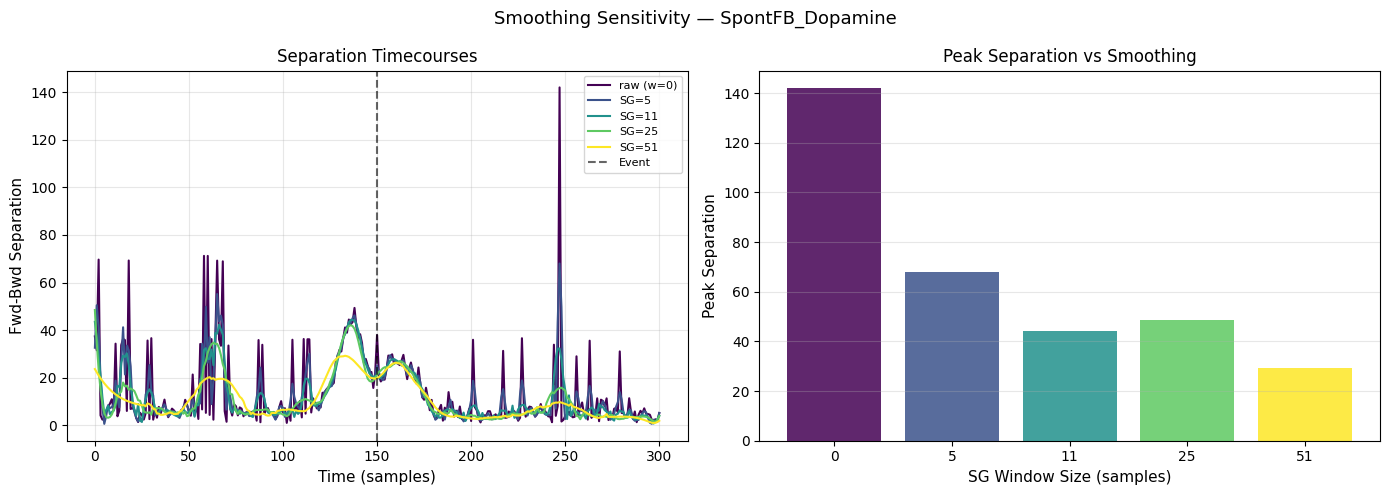


SpontFB_Dopamine:
 sg_window  mean_sep  peak_sep  post_event_mean  cohens_d  divergence_onset_idx  auc_above_baseline
         0   13.6749  141.9719          10.5948   -0.3633               97.0000           1477.0389
         5   13.1375   67.9919          10.1129   -0.4594               96.0000           1123.2853
        11   12.2026   44.3335           9.1015   -0.5118                   NaN           1030.6157
        25   11.1908   48.4578           8.2355   -0.5368                   NaN            900.0058
        51   10.5073   29.2355           7.8044   -0.7186                   NaN            715.2652



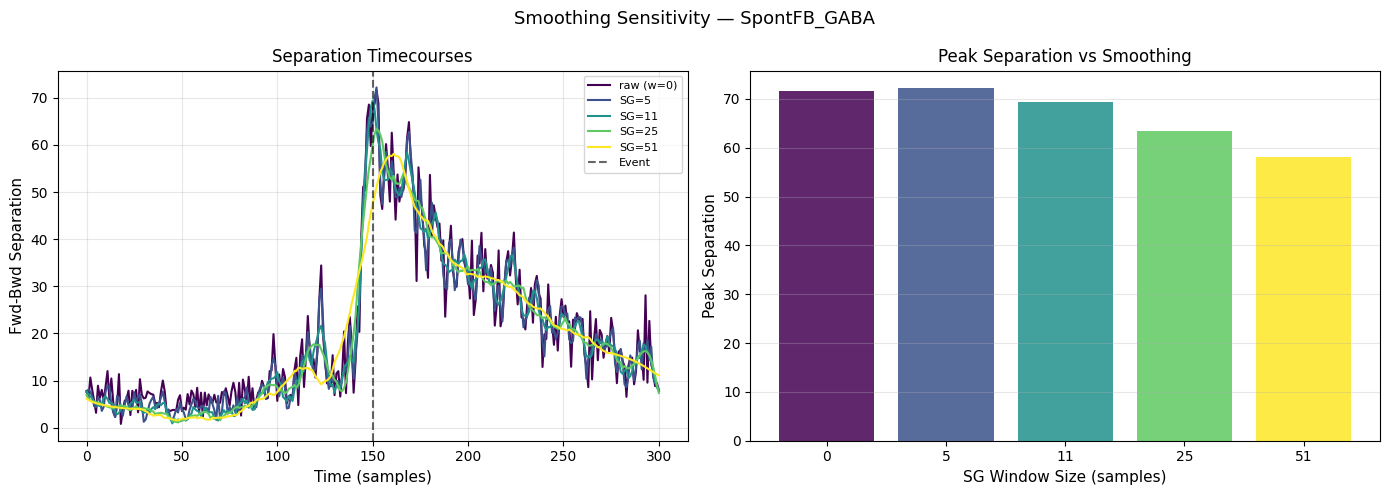


SpontFB_GABA:
 sg_window  mean_sep  peak_sep  post_event_mean  cohens_d  divergence_onset_idx  auc_above_baseline
         0   20.6706   71.6649          30.5745    1.8414                     0           3487.2185
         5   19.9765   72.2052          30.3255    1.9155                     0           3603.0540
        11   19.5950   69.4132          30.1925    1.9693                     0           3686.8367
        25   19.3926   63.4628          30.2010    2.1815                     0           3730.4658
        51   19.1648   58.1169          29.9852    2.4127                     0           3745.3635



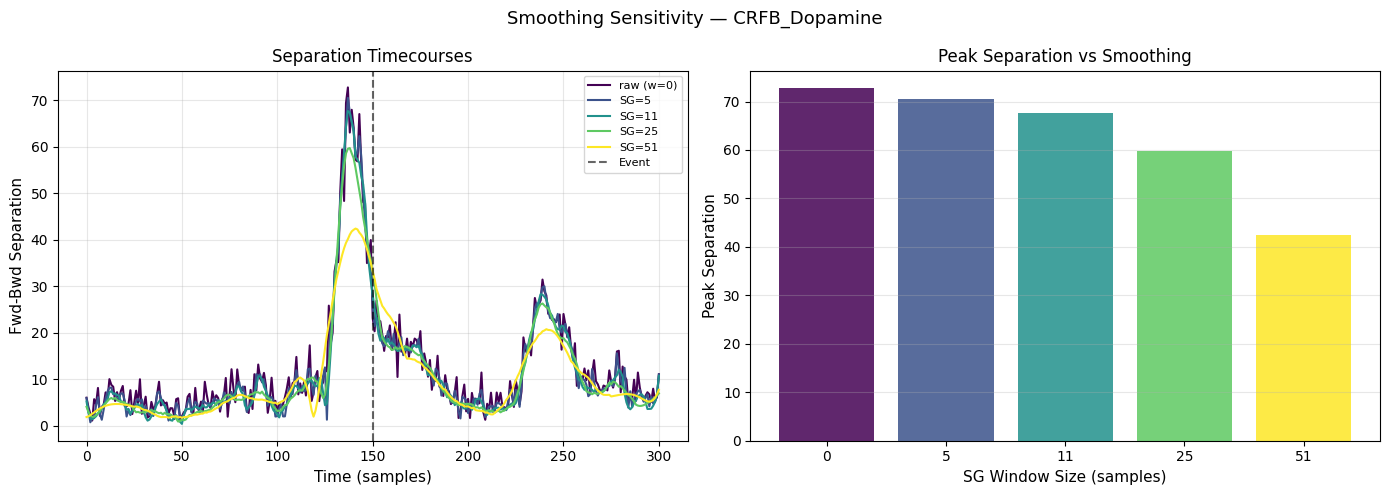


CRFB_Dopamine:
 sg_window  mean_sep  peak_sep  post_event_mean  cohens_d divergence_onset_idx  auc_above_baseline
         0   12.6214   72.7447          12.4174   -0.0248                 None           1252.9727
         5   11.9243   70.4951          11.8305   -0.0114                 None           1261.5403
        11   11.4476   67.6803          11.4278   -0.0024                 None           1268.0730
        25   11.0461   59.7151          11.2519    0.0271                 None           1255.2292
        51   10.4814   42.4165          11.3006    0.1379                 None           1188.4470



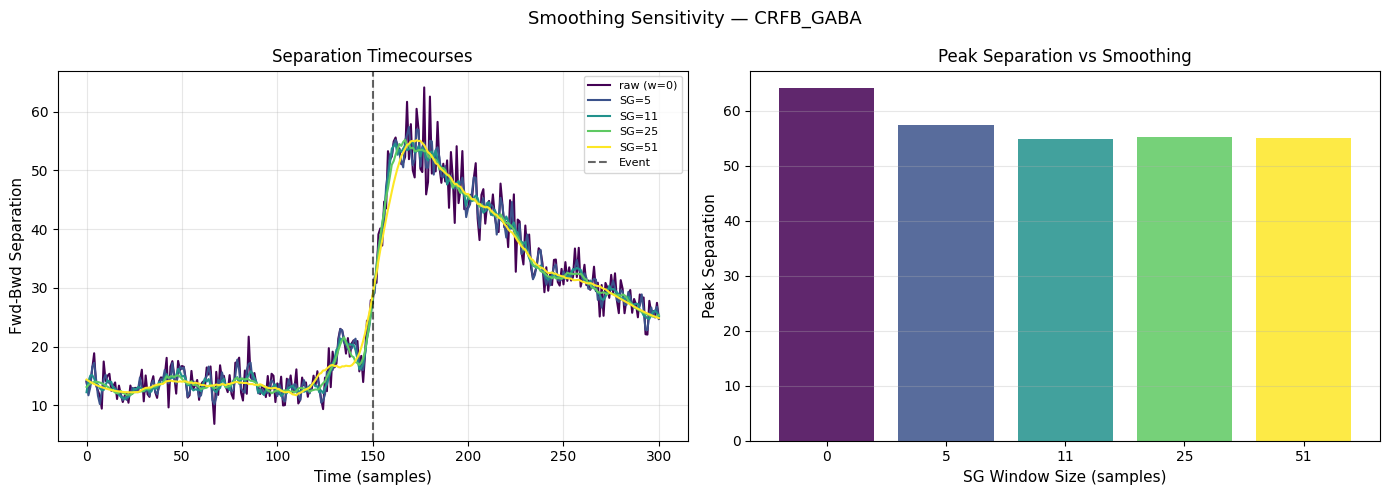


CRFB_GABA:
 sg_window  mean_sep  peak_sep  post_event_mean  cohens_d  divergence_onset_idx  auc_above_baseline
         0   26.8806   64.1159          39.1053    7.3136                     0           3895.1006
         5   26.6738   57.3901          38.9368    8.4793                     0           3876.6543
        11   26.5621   54.9203          38.8118    9.4531                     0           3849.4275
        25   26.4657   55.2093          38.6910   10.1128                     0           3828.3450
        51   26.3505   55.1313          38.4699   10.2182                     0           3784.5801



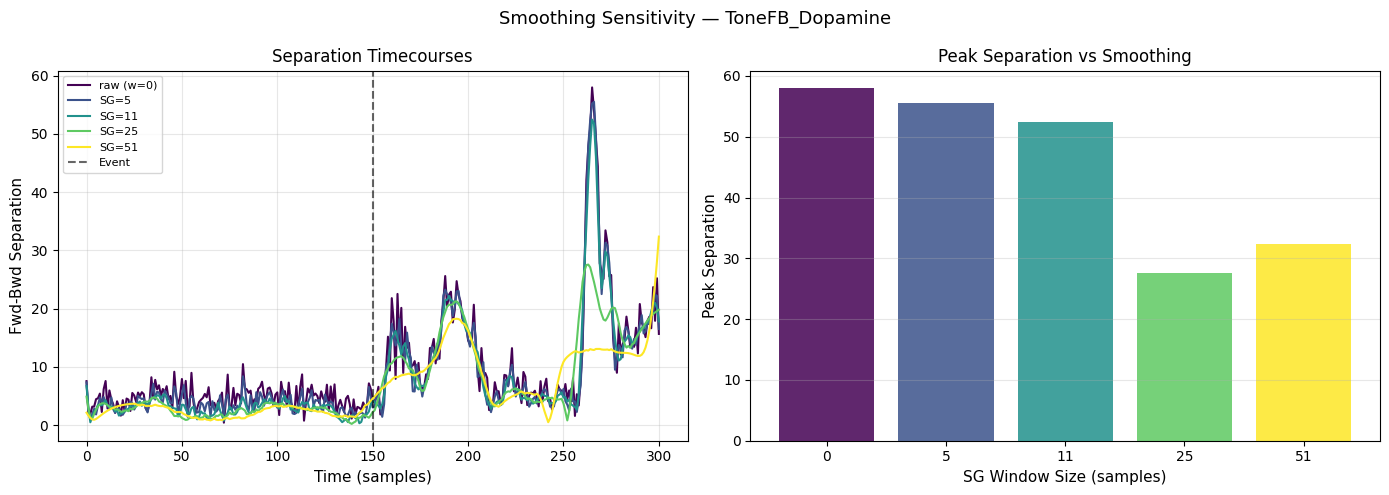


ToneFB_Dopamine:
 sg_window  mean_sep  peak_sep  post_event_mean  cohens_d  divergence_onset_idx  auc_above_baseline
         0    9.1976   57.9819          13.7019    4.9049                     7           1502.7614
         5    8.4463   55.5059          13.1704    6.6362                     7           1529.7242
        11    7.8171   52.4637          12.7433    8.4824                     7           1563.5632
        25    7.1223   27.5575          11.7378    8.9924                     3           1465.8430
        51    6.2856   32.3642          10.2748    8.7648                     0           1273.3358



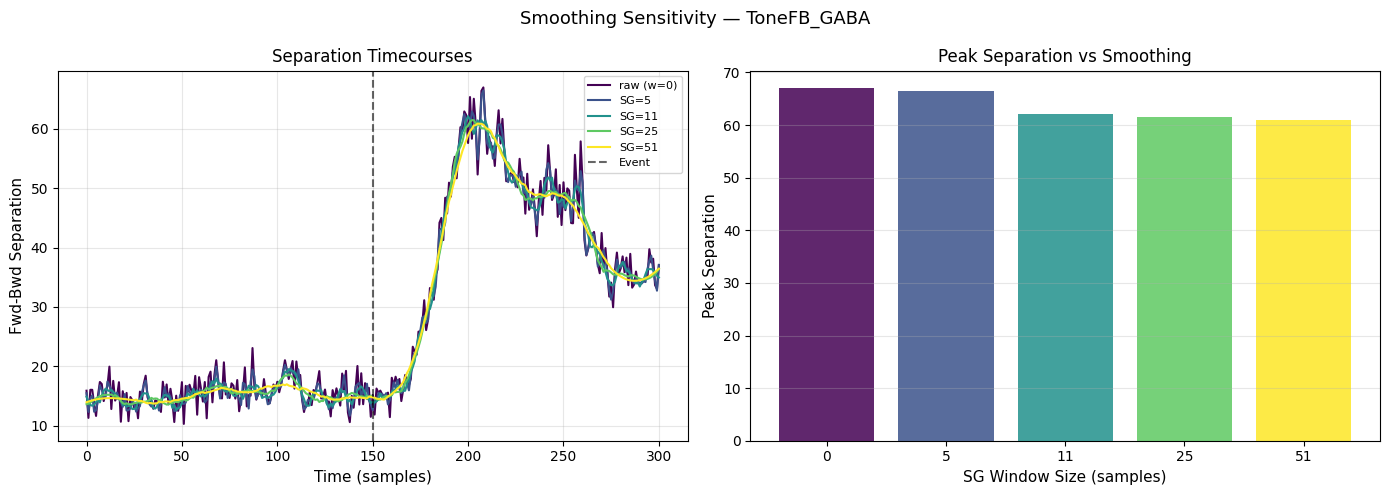


ToneFB_GABA:
 sg_window  mean_sep  peak_sep  post_event_mean  cohens_d  divergence_onset_idx  auc_above_baseline
         0   28.4214   67.0074          41.2271   10.4637                    21           4036.0684
         5   28.1839   66.5046          40.9965   14.0960                    21           3999.9058
        11   28.0793   62.1734          40.8888   17.3995                    20           3972.9229
        25   28.0335   61.4918          40.8303   22.6293                    18           3948.8455
        51   28.0136   60.9073          40.8157   28.4720                    16           3944.7224



In [4]:
# B. Smoothing sensitivity across all dataset × population combos
sg_windows = [0, 5, 11, 25, 51]

smoothing_results = {}
for key, r in results.items():
    summary_df, trajs = run_smoothing_sensitivity(r, sg_windows=sg_windows, sg_order=SG_ORDER)
    smoothing_results[key] = (summary_df, trajs)

    fig = plot_smoothing_sensitivity(
        summary_df, trajs, event_idx=WINDOW,
        title=f"Smoothing Sensitivity — {key}")
    plt.show()

    # Print summary table
    print(f"\n{key}:")
    print(summary_df.to_string(index=False, float_format='{:.4f}'.format))
    print()

In [5]:
# B. Summary: peak separation ratio (raw / default smoothing) for each combo
print("=" * 70)
print("Smoothing Sensitivity Summary: peak_sep(raw) / peak_sep(SG=11)")
print("=" * 70)
for key, (sdf, _) in smoothing_results.items():
    raw_peak = sdf.loc[sdf['sg_window'] == 0, 'peak_sep'].values[0]
    sg11_peak = sdf.loc[sdf['sg_window'] == 11, 'peak_sep'].values[0]
    ratio = raw_peak / (sg11_peak + 1e-12)
    flag = "OK" if ratio > 0.5 else "SUSPICIOUS"
    print(f"  {key:25s}  raw={raw_peak:.4f}  sg11={sg11_peak:.4f}  "
          f"ratio={ratio:.2f}  [{flag}]")

print("\nIf ratio > 0.5: separation is genuine (visible without heavy smoothing)")
print("If ratio < 0.5: separation may depend on smoothing — investigate further")

Smoothing Sensitivity Summary: peak_sep(raw) / peak_sep(SG=11)
  SpontFB_Dopamine           raw=141.9719  sg11=44.3335  ratio=3.20  [OK]
  SpontFB_GABA               raw=71.6649  sg11=69.4132  ratio=1.03  [OK]
  CRFB_Dopamine              raw=72.7447  sg11=67.6803  ratio=1.07  [OK]
  CRFB_GABA                  raw=64.1159  sg11=54.9203  ratio=1.17  [OK]
  ToneFB_Dopamine            raw=57.9819  sg11=52.4637  ratio=1.11  [OK]
  ToneFB_GABA                raw=67.0074  sg11=62.1734  ratio=1.08  [OK]

If ratio > 0.5: separation is genuine (visible without heavy smoothing)
If ratio < 0.5: separation may depend on smoothing — investigate further


---
# C. Reward Delivery Timing Jitter Analysis

**Core question:** Is the second DA burst in ToneFB (near t=700) **movement-locked** or **reward-locked**?

**Logic:** Reward is fixed at exactly t=700 (100ms post-CS). CR onset timing varies (~30–100 timesteps jitter). This creates an asymmetry:
- **Reward-locked burst** → sharp peak at t=700 in CS-aligned averages (no jitter)
- **Movement-locked burst** → temporally smeared by CR onset jitter distribution

### Three sub-analyses:
- **C1:** Burst sharpness (FWHM) — compare ToneFB vs CRFB DA speed peaks
- **C2:** Jitter smearing simulation — convolve clean burst with CR-onset jitter, fit to observed
- **C3:** Pre- vs post-reward separation — does direction separation build before or after t=700?

In [6]:
# C1. Burst sharpness: compare FWHM of DA speed peaks near reward time (t=700)
# Speed = Euclidean distance per timestep in PC space

def compute_pc_speed(result, use_smoothed=True):
    """Compute trajectory speed from result's smooth_data or window_data."""
    if use_smoothed and 'smooth_data' in result:
        sd = result['smooth_data']
        fwd = np.array(sd['fwd_smooth'])
        bwd = np.array(sd['bwd_smooth'])
    else:
        wd = result['window_data']
        fwd = np.array(wd['fwd'])
        bwd = np.array(wd['bwd'])
    # Mean trajectory speed (average of fwd and bwd)
    fwd_speed = np.sqrt(np.sum(np.diff(fwd, axis=1)**2, axis=0))
    bwd_speed = np.sqrt(np.sum(np.diff(bwd, axis=1)**2, axis=0))
    return (fwd_speed + bwd_speed) / 2


# Compute speed profiles for ToneFB and CRFB (DA population)
burst_results = {}
for ds_name in ['ToneFB', 'CRFB']:
    key = f"{ds_name}_Dopamine"
    if key not in results:
        print(f"SKIP {key} — not available")
        continue

    speed = compute_pc_speed(results[key], use_smoothed=True)

    # search_window relative to the windowed array:
    # Window starts at EVENT_IDX - WINDOW = 450, so reward at t=700 → index 250
    # search around reward ± 50 samples = [200, 300] in window coords
    # NOTE: window_data has 2*WINDOW+1 = 301 samples; speed (from diff) has 300
    reward_in_window = REWARD_IDX - (EVENT_IDX - WINDOW)
    sw = (reward_in_window - 50, reward_in_window + 50)
    sharpness = compute_burst_sharpness(speed, search_window=sw, event_offset=0)
    burst_results[ds_name] = {'speed': speed, 'sharpness': sharpness}

    print(f"\n{key} burst sharpness (search window {sw}):")
    for k, v in sharpness.items():
        if isinstance(v, float):
            print(f"  {k:20s}: {v:.3f}")
        else:
            print(f"  {k:20s}: {v}")

# Compare
if len(burst_results) == 2:
    tone_s = burst_results['ToneFB']['sharpness']['sigma_samples']
    crfb_s = burst_results['CRFB']['sharpness']['sigma_samples']
    print(f"\n{'='*60}")
    print(f"ToneFB burst σ: {tone_s:.2f} samples  |  CRFB burst σ: {crfb_s:.2f} samples")
    if not np.isnan(tone_s) and not np.isnan(crfb_s):
        if tone_s < crfb_s * 0.8:
            print("→ ToneFB burst is SHARPER → consistent with REWARD-LOCKED hypothesis")
        elif tone_s > crfb_s * 1.2:
            print("→ ToneFB burst is BROADER → consistent with MOVEMENT-LOCKED (more jitter)")
        else:
            print("→ Similar width — ambiguous (both hypotheses plausible)")
    print(f"{'='*60}")


ToneFB_Dopamine burst sharpness (search window (200, 300)):
  peak_t              : 261
  peak_height         : 29.54140853881836
  sigma_samples       : 5.557
  fwhm_samples        : 13.087
  fit_r2              : 0.907
  gaussian_fitted     : True

CRFB_Dopamine burst sharpness (search window (200, 300)):
  peak_t              : 241
  peak_height         : 4.238473415374756
  sigma_samples       : 9.940
  fwhm_samples        : 23.409
  fit_r2              : 0.742
  gaussian_fitted     : True

ToneFB burst σ: 5.56 samples  |  CRFB burst σ: 9.94 samples
→ ToneFB burst is SHARPER → consistent with REWARD-LOCKED hypothesis


Jitter Smearing Simulation Results:
 sigma                       hypothesis  r2_vs_observed  mse_vs_observed
     3     movement-locked (jitter σ=3)         -0.1812          65.0638
     5     movement-locked (jitter σ=5)         -0.1546          63.5971
    10    movement-locked (jitter σ=10)         -0.0828          59.6420
    20    movement-locked (jitter σ=20)         -0.0202          56.1964
    50    movement-locked (jitter σ=50)         -0.0334          56.9250
     0 reward-locked (sharp, no jitter)         -0.2018          66.1979


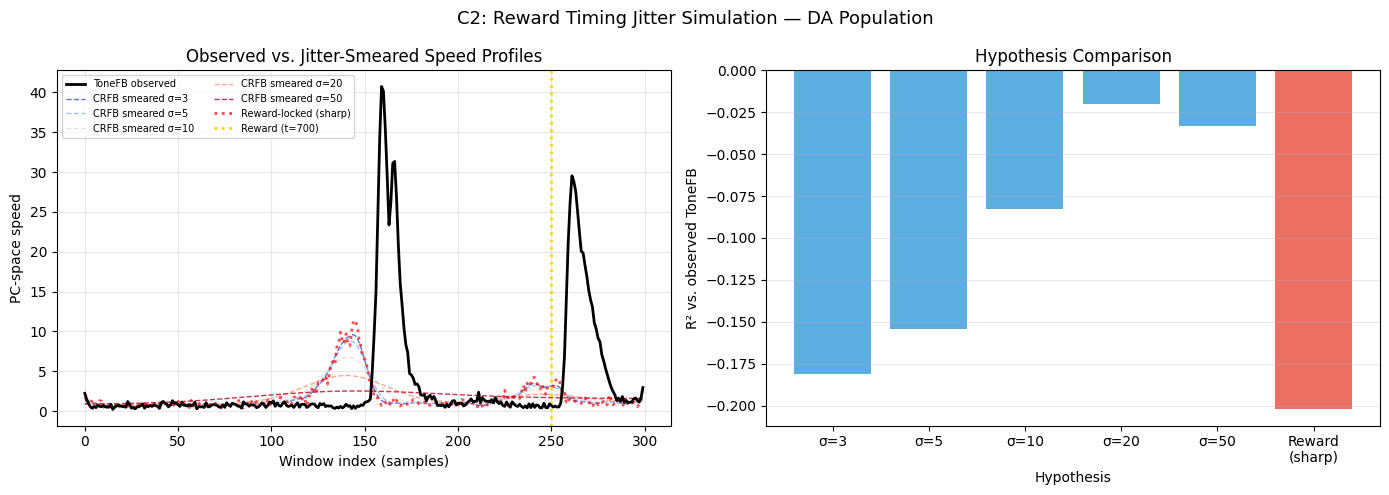


Best-fitting hypothesis: movement-locked (jitter σ=20)  (R² = -0.0202)


In [7]:
# C2. Jitter smearing simulation
# Take the CRFB DA speed profile as the "clean" (unsmeared) reference burst,
# convolve with Gaussian jitter models, compare to observed ToneFB burst.

if 'CRFB' in burst_results and 'ToneFB' in burst_results:
    clean_burst = burst_results['CRFB']['speed']
    observed_burst = burst_results['ToneFB']['speed']

    # Start from sigma=3 (not 0) to avoid duplicating the reward-locked baseline
    jitter_sigmas = [3, 5, 10, 20, 50]
    jitter_df, smeared_bursts = simulate_jitter_smearing(
        clean_burst, jitter_sigmas, observed_burst)

    print("Jitter Smearing Simulation Results:")
    print(jitter_df.to_string(index=False, float_format='{:.4f}'.format))

    # Plot: observed vs smeared hypotheses
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    t = np.arange(len(observed_burst))
    ax.plot(t, observed_burst, 'k-', linewidth=2, label='ToneFB observed', zorder=10)
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(jitter_sigmas)))
    for sigma, col in zip(jitter_sigmas, colors):
        s = smeared_bursts[sigma][:len(t)]
        ax.plot(t, s, '--', color=col, linewidth=1, alpha=0.8,
                label=f'CRFB smeared σ={sigma}')
    # Also show the reward-locked (unsmeared) hypothesis
    ax.plot(t, clean_burst[:len(t)], 'r:', linewidth=2, alpha=0.7,
            label='Reward-locked (sharp)')
    ax.axvline(REWARD_IDX - (EVENT_IDX - WINDOW), color='gold', linestyle=':',
               linewidth=2, label='Reward (t=700)')
    ax.set_xlabel('Window index (samples)')
    ax.set_ylabel('PC-space speed')
    ax.set_title('Observed vs. Jitter-Smeared Speed Profiles')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    # R² bar chart
    ax2 = axes[1]
    movement_rows = jitter_df[jitter_df['hypothesis'].str.startswith('movement')]
    reward_row = jitter_df[jitter_df['hypothesis'].str.startswith('reward')]

    all_labels = [f'σ={int(s)}' for s in movement_rows['sigma']]
    all_r2s = list(movement_rows['r2_vs_observed'].values)
    all_colors = ['#3498db'] * len(all_labels)
    if not reward_row.empty:
        all_labels.append('Reward\n(sharp)')
        all_r2s.append(reward_row['r2_vs_observed'].values[0])
        all_colors.append('#e74c3c')

    ax2.bar(all_labels, all_r2s, color=all_colors, alpha=0.8)
    ax2.set_xlabel('Hypothesis')
    ax2.set_ylabel('R² vs. observed ToneFB')
    ax2.set_title('Hypothesis Comparison')
    ax2.grid(True, alpha=0.3, axis='y')

    fig.suptitle('C2: Reward Timing Jitter Simulation — DA Population', fontsize=13)
    fig.tight_layout()
    plt.show()

    # Best fit
    best = jitter_df.loc[jitter_df['r2_vs_observed'].idxmax()]
    print(f"\nBest-fitting hypothesis: {best['hypothesis']}  (R² = {best['r2_vs_observed']:.4f})")
else:
    print("Need both CRFB and ToneFB DA results for jitter simulation")

In [8]:
# C3. Pre- vs post-reward separation
# If direction separation builds BEFORE t=700, it is movement-driven.
# If separation only appears AT/AFTER t=700, it could be reward-driven.

print("C3: Pre- vs Post-Reward Direction Separation")
print("=" * 65)
print(f"{'Analysis':25s}  {'Pre [640,700)':>14s}  {'Post [700,750)':>14s}  {'Ratio':>8s}  Interpretation")
print("-" * 65)

for pop_label in ['Dopamine', 'GABA']:
    key = f"ToneFB_{pop_label}"
    if key not in results:
        continue

    # Use smooth_data for consistency with rest of pipeline
    sd = results[key]['smooth_data']
    fwd = np.array(sd['fwd_smooth'])
    bwd = np.array(sd['bwd_smooth'])

    sep_info = compute_pre_post_reward_separation(
        fwd, bwd, reward_idx=REWARD_IDX, window=50,   # window=50 to stay within 301-sample bounds
        event_offset=EVENT_IDX - WINDOW)

    interp = ""
    if sep_info['ratio'] < 1.5:
        interp = "Separation present pre-reward → MOVEMENT"
    elif sep_info['ratio'] > 3.0:
        interp = "Separation jumps at reward → REWARD"
    else:
        interp = "Moderate increase — ambiguous"

    print(f"  {key:23s}  {sep_info['pre_mean']:14.4f}  {sep_info['post_mean']:14.4f}  "
          f"{sep_info['ratio']:8.2f}  {interp}")

print()
print("If DA shows a jump at reward but GABA does not, DA may encode RPE.")
print("If both show similar pre/post patterns, the signal is likely kinematic.")

C3: Pre- vs Post-Reward Direction Separation
Analysis                    Pre [640,700)  Post [700,750)     Ratio  Interpretation
-----------------------------------------------------------------
  ToneFB_Dopamine                  6.1926         19.4519      3.14  Separation jumps at reward → REWARD
  ToneFB_GABA                     53.5930         39.2919      0.73  Separation present pre-reward → MOVEMENT

If DA shows a jump at reward but GABA does not, DA may encode RPE.
If both show similar pre/post patterns, the signal is likely kinematic.


**Note:** This analysis uses trial-averaged data. Once single-trial data arrives, C2 can be replaced
with real per-trial reward/movement alignment — the gold standard test. The framework functions
(`compute_burst_sharpness`, `simulate_jitter_smearing`) are designed for forward-compatibility.

---
# D. Demixed PCA (dPCA)

**Question:** What fraction of DA/GABA population variance is attributable to **movement direction** vs. **time** vs. **direction×time interaction**?

dPCA (Kobak et al., 2016) decomposes the data tensor into components indexed by task variables:
- `'t'` — time (temporal dynamics shared across conditions)
- `'s'` — stimulus/direction (forward vs. backward separation)
- `'st'` — interaction (direction-dependent temporal dynamics)

**Key prediction:**
- If DA encodes movement: `'s'` (direction) fraction should be similar across SpontFB and ToneFB
- If DA encodes RPE: `'s'` fraction should drop in ToneFB (reward contamination) and `'st'` should rise

**Caveat:** Without per-trial noise covariance, regularization is approximate. Results will be refined once single-trial data is available.

In [9]:
# D. Run dPCA on all dataset × population combinations
dpca_results = {}
var_fracs_all = {}

for ds_name, ds_cfg in DATASETS.items():
    data = raw_data[ds_name]
    for pop_label, groups in combos.items():
        key = f"{ds_name}_{pop_label}"

        try:
            X, timesteps, stats = extract_neuron_data(data, groups)
            X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
            n_neurons, total_cols = X_arr.shape
            half = total_cols // 2
            X_fwd = X_arr[:, :half]   # forward half
            X_bwd = X_arr[:, half:]   # backward half

            if n_neurons < 5:
                print(f"SKIP {key:25s}  n={n_neurons} < 5 (too few for dPCA)")
                continue

            dpca_obj, var_fracs, Z = run_dpca(X_fwd, X_bwd, n_components=N_COMPONENTS)
            dpca_results[key] = {'dpca': dpca_obj, 'var_fracs': var_fracs, 'Z': Z}
            var_fracs_all[key] = var_fracs

            print(f"OK  {key:25s}  n={n_neurons:4d}  "
                  f"time={var_fracs.get('t',0):.3f}  "
                  f"dir={var_fracs.get('s',0):.3f}  "
                  f"dir×time={var_fracs.get('st',0):.3f}")
        except Exception as e:
            print(f"FAIL {key:25s}  {e}")

print(f"\ndPCA analyses completed: {len(dpca_results)}")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
FAIL SpontFB_Dopamine           To optimize the regularization parameter, the trial-by-trial data trialX needs to be provided.


You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
FAIL SpontFB_GABA               To optimize the regularization parameter, the trial-by-trial data trialX needs to be provided.
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set

Start optimizing regularization.
FAIL CRFB_Dopamine              To optimize the regularization parameter, the trial-by-trial data trialX needs to be provided.
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
FAIL CRFB_GABA                  To optimize the regularization parameter, the trial-by-trial data trialX needs to be provided.
You chose to determine the regularization parameter automati

In [10]:
# D. Stacked bar chart: variance fractions by marginalization
if var_fracs_all:
    fig = plot_dpca_variance_fractions(var_fracs_all,
                                        title="dPCA Variance Decomposition: Direction vs. Time")
    plt.show()

    # Print comparison table
    print("\ndPCA Variance Fractions Summary:")
    print(f"{'Analysis':25s}  {'Time':>8s}  {'Direction':>10s}  {'Dir×Time':>10s}  {'Dir/Time':>10s}")
    print("-" * 70)
    for key, vf in var_fracs_all.items():
        t_frac = vf.get('t', 0)
        s_frac = vf.get('s', 0)
        st_frac = vf.get('st', 0)
        ratio = s_frac / (t_frac + 1e-10)
        print(f"  {key:23s}  {t_frac:8.3f}  {s_frac:10.3f}  {st_frac:10.3f}  {ratio:10.2f}")

    print("\nInterpretation:")
    print("  Dir/Time > 1.0 → Direction dominates (supports movement hypothesis)")
    print("  Dir/Time < 0.5 → Time dominates (direction is secondary)")
    print("  High Dir×Time  → Context-dependent direction coding (possible reward interaction)")

In [11]:
# D. Plot dPCA timecourses for key analyses (direction component)
for key in ['SpontFB_Dopamine', 'ToneFB_Dopamine', 'SpontFB_GABA', 'ToneFB_GABA']:
    if key in dpca_results:
        Z = dpca_results[key]['Z']
        fig = plot_dpca_timecourses(Z, title=f"dPCA Components — {key}")
        plt.show()

---
# E. Regression-Based Confound Removal

**Question:** In ToneFB, forward = rewarded and backward = unrewarded. Does PCA separation
reflect reward expectation (RPE) rather than movement direction?

**Method:** Partial out the reward-correlated variance from each neuron's firing rate, then
re-run PCA and check if fwd/bwd separation persists.

**Two regressors tested:**
1. **Boxcar** — binary step function: 1 from t=700 (reward) to end, 0 before. Simple, interpretable.
2. **Data-driven** — population mean post-reward response minus pre-tone baseline. More realistic,
   orthogonalized w.r.t. movement signal (from SpontFB) to avoid over-removing.

**Interpretation:**
- Separation reduced < 50% → movement signal is genuine, independent of reward
- Separation reduced > 80% → separation was primarily reward-driven

In [12]:
# E. Regression-based confound removal on ToneFB DA neurons
# Extract ToneFB DA firing rates (fwd/bwd halves)
tone_data = raw_data['ToneFB']
X_tone, timesteps_tone, stats_tone = extract_neuron_data(tone_data, DA_GROUPS)
X_tone_arr = X_tone.values if hasattr(X_tone, 'values') else np.asarray(X_tone)
half = timesteps_tone
X_tone_fwd = X_tone_arr[:, :half]
X_tone_bwd = X_tone_arr[:, half:]

# Also get SpontFB DA as movement reference (for data-driven orthogonalization)
spont_data = raw_data['SpontFB']
X_spont, timesteps_spont, _ = extract_neuron_data(spont_data, DA_GROUPS)
X_spont_arr = X_spont.values if hasattr(X_spont, 'values') else np.asarray(X_spont)
# Match number of neurons (use min of both)
n_match = min(X_tone_fwd.shape[0], X_spont_arr.shape[0])
ref_fwd = X_spont_arr[:n_match, :half] if X_spont_arr.shape[1] >= half else None

print(f"ToneFB DA: {X_tone_fwd.shape[0]} neurons × {half} timesteps")
print(f"SpontFB DA reference: {n_match} matched neurons")

# Run both methods
confound_results = partial_out_reward_regressor(
    X_tone_fwd, X_tone_bwd,
    reward_onset_idx=REWARD_IDX,
    method='both',
    reference_X_fwd=ref_fwd,
    event_offset=0,
    baseline_window=(450, 600))

for method_name, res in confound_results.items():
    print(f"\n{method_name.upper()} method:")
    print(f"  Variance removed: {res['variance_removed_frac']*100:.1f}%")
    print(f"  Mean |beta|:      {np.mean(np.abs(res['beta'])):.4f}")
    print(f"  Max |beta|:       {np.max(np.abs(res['beta'])):.4f}")

ToneFB DA: 497 neurons × 1201 timesteps
SpontFB DA reference: 497 matched neurons

BOXCAR method:
  Variance removed: 0.7%
  Mean |beta|:      0.2355
  Max |beta|:       2.2615

DATA_DRIVEN method:
  Variance removed: 2.4%
  Mean |beta|:      0.6240
  Max |beta|:       3.9503



BOXCAR — Before/After Comparison:
  EVR total:      0.276 → 0.276  (Δ = 0.0%)
  Peak sep:       57.9819 → 56.5941  (Δ = 2.4%)
  Post-event sep: 7.3985 → 7.0832  (Δ = 4.3%)

DATA_DRIVEN — Before/After Comparison:
  EVR total:      0.276 → 0.271  (Δ = 1.9%)
  Peak sep:       57.9819 → 48.1327  (Δ = 17.0%)
  Post-event sep: 7.3985 → 8.8379  (Δ = -19.5%)


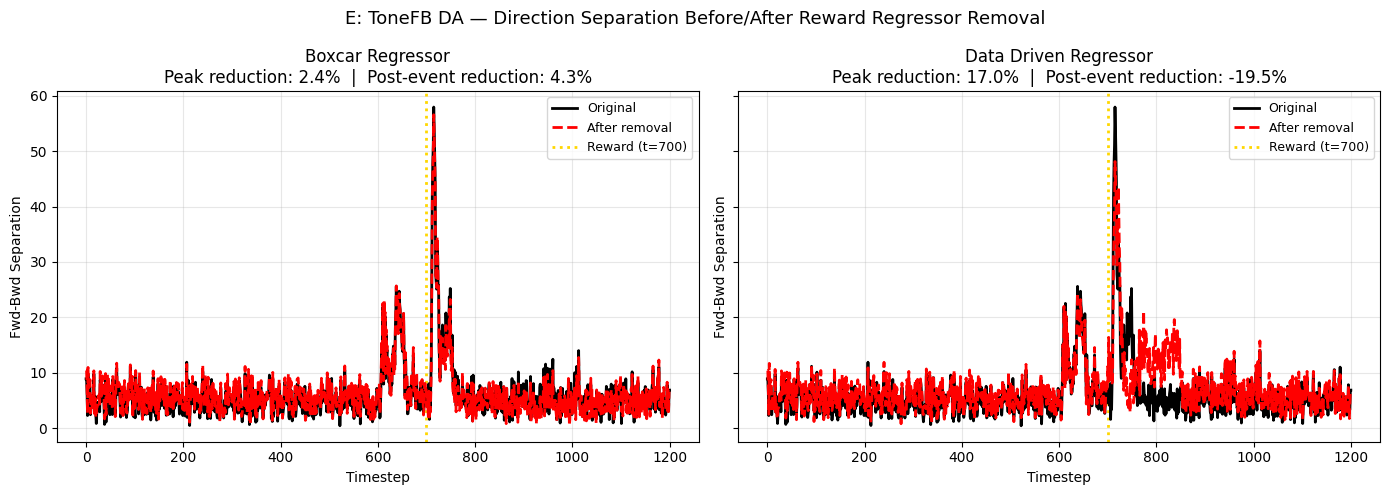


Conclusion: if separation persists (< 50% reduction), the signal is movement-driven.


In [13]:
# E. Compare PCA separation before and after confound removal (both methods)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (method_name, res) in enumerate(confound_results.items()):
    comparison = compare_pca_before_after_confound_removal(
        X_tone_fwd, X_tone_bwd,
        res['X_fwd_resid'], res['X_bwd_resid'],
        n_components=N_COMPONENTS)

    ax = axes[idx]
    t = np.arange(len(comparison['original']['sep_curve']))
    ax.plot(t, comparison['original']['sep_curve'], 'k-', linewidth=2,
            label='Original', zorder=5)
    ax.plot(t, comparison['residual']['sep_curve'], 'r--', linewidth=2,
            label='After removal', zorder=5)
    ax.axvline(REWARD_IDX, color='gold', linestyle=':', linewidth=2,
               label='Reward (t=700)')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Fwd-Bwd Separation')
    ax.set_title(f'{method_name.replace("_"," ").title()} Regressor\n'
                 f'Peak reduction: {comparison["peak_sep_reduction_pct"]:.1f}%  |  '
                 f'Post-event reduction: {comparison["post_event_reduction_pct"]:.1f}%')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    print(f"\n{method_name.upper()} — Before/After Comparison:")
    print(f"  EVR total:      {comparison['original']['evr_total']:.3f} → "
          f"{comparison['residual']['evr_total']:.3f}  "
          f"(Δ = {comparison['evr_total_reduction_pct']:.1f}%)")
    print(f"  Peak sep:       {comparison['original']['peak_sep']:.4f} → "
          f"{comparison['residual']['peak_sep']:.4f}  "
          f"(Δ = {comparison['peak_sep_reduction_pct']:.1f}%)")
    print(f"  Post-event sep: {comparison['original']['post_event_mean']:.4f} → "
          f"{comparison['residual']['post_event_mean']:.4f}  "
          f"(Δ = {comparison['post_event_reduction_pct']:.1f}%)")

fig.suptitle('E: ToneFB DA — Direction Separation Before/After Reward Regressor Removal',
             fontsize=13)
fig.tight_layout()
plt.show()

print("\nConclusion: if separation persists (< 50% reduction), the signal is movement-driven.")

In [14]:
# E. Cross-project residual ToneFB onto SpontFB PCA (group-averaged approach)
# SpontFB and ToneFB have different neurons (different sessions), so we use
# group-averaged data (4 pseudo-neurons per population) for cross-projection,
# matching the existing cross-dataset framework.

spont_data = raw_data['SpontFB']
tone_data_raw = raw_data['ToneFB']

X_spont_grp, ts_spont, labels_spont = extract_group_averaged_data(spont_data, DA_GROUPS)
spont_grp_pca = fit_pca(X_spont_grp, n_components=min(N_COMPONENTS, len(labels_spont) - 1))

for method_name, res in confound_results.items():
    # Group-average the residual ToneFB data
    # We need to reconstruct group-averaged residuals from per-neuron residuals
    # Since the groups have known boundaries, we average within each group
    X_fwd_r = res['X_fwd_resid']
    X_bwd_r = res['X_bwd_resid']
    X_resid_full = np.concatenate([X_fwd_r, X_bwd_r], axis=1)

    # Also compute for original (unresidualized) ToneFB
    X_orig_full = np.concatenate([X_tone_fwd, X_tone_bwd], axis=1)

    # Use group-averaged ToneFB for cross-projection
    X_tone_grp, ts_tone, labels_tone = extract_group_averaged_data(tone_data_raw, DA_GROUPS)

    # Check dimension match
    n_grp_spont = spont_grp_pca.components_.shape[1]
    if X_tone_grp.shape[0] != n_grp_spont:
        print(f"  {method_name}: group count mismatch "
              f"({X_tone_grp.shape[0]} vs {n_grp_spont}), skipping")
        continue

    r2_orig = compute_reconstruction_r2(spont_grp_pca, X_tone_grp)

    # For residual cross-projection: we can't easily group-average the residuals
    # without knowing group boundaries. Instead, compare within-dataset PCA metrics.
    print(f"\n{method_name.upper()} — Cross-projection (group-averaged SpontFB PCA):")
    print(f"  Original ToneFB (group-avg) R²:  {r2_orig:.4f}")
    print(f"  Note: Residual cross-projection requires group-level residuals.")
    print(f"  Within-dataset separation reduction is the primary metric (see above).")

print("\nFor same-neuron cross-projection, use CRFB↔ToneFB (same recording session).")


BOXCAR — Cross-projection (group-averaged SpontFB PCA):
  Original ToneFB (group-avg) R²:  0.9438
  Note: Residual cross-projection requires group-level residuals.
  Within-dataset separation reduction is the primary metric (see above).

DATA_DRIVEN — Cross-projection (group-averaged SpontFB PCA):
  Original ToneFB (group-avg) R²:  0.9438
  Note: Residual cross-projection requires group-level residuals.
  Within-dataset separation reduction is the primary metric (see above).

For same-neuron cross-projection, use CRFB↔ToneFB (same recording session).


---
# P1. Population Vector Correlation

Model-free measure of representational similarity: Pearson correlation between forward and backward
population vectors (all neurons) at each timepoint. Unlike PCA-based separation, this does not
assume any particular subspace structure.

**Interpretation:** High correlation = similar population state (similar activity pattern).
Drop in correlation = population differentiates between forward and backward conditions.

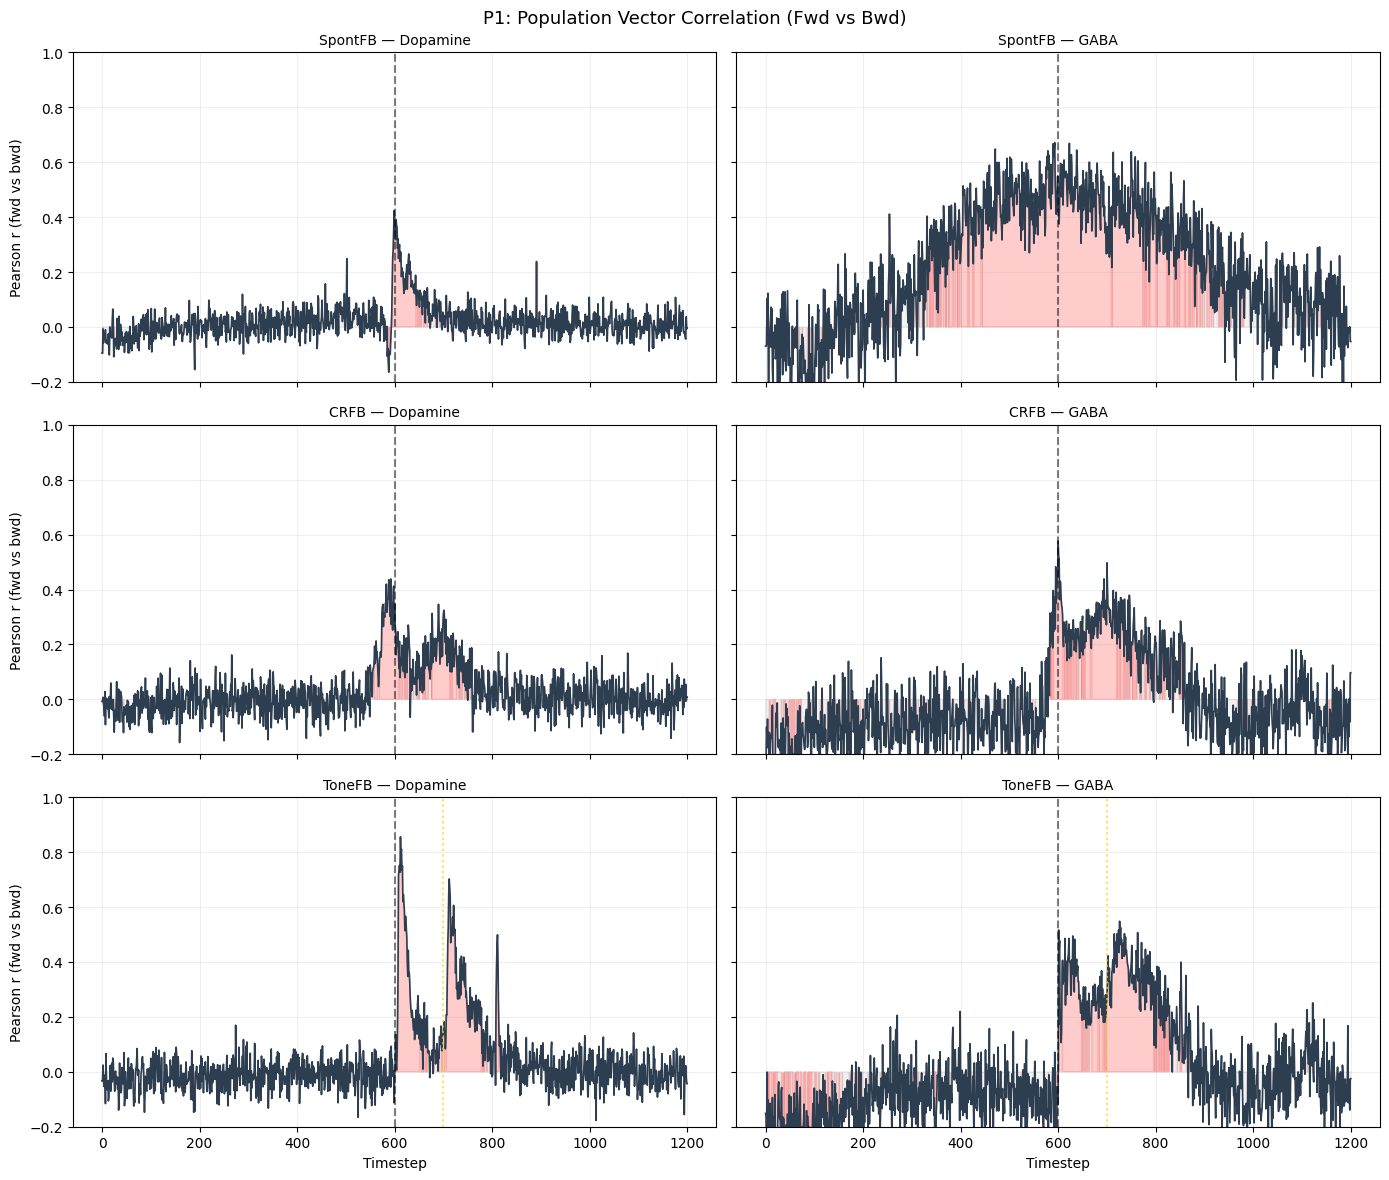

In [15]:
# P1. Population vector correlation for all dataset × population combos
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 4 * len(DATASETS)),
                          sharex=True, sharey=True)

for row, ds_name in enumerate(DATASETS):
    data = raw_data[ds_name]
    for col, (pop_label, groups) in enumerate(combos.items()):
        ax = axes[row, col] if len(DATASETS) > 1 else axes[col]
        try:
            X, timesteps, _ = extract_neuron_data(data, groups)
            X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
            half = timesteps
            X_fwd = X_arr[:, :half]
            X_bwd = X_arr[:, half:]

            r_vals, p_vals = compute_population_vector_correlation(X_fwd, X_bwd)

            t = np.arange(len(r_vals))
            ax.plot(t, r_vals, linewidth=1.2, color='#2c3e50')
            # Highlight significant drops (p < 0.01)
            sig = p_vals < 0.01
            ax.fill_between(t, r_vals, where=~sig, alpha=0.1, color='grey')
            ax.fill_between(t, r_vals, where=sig, alpha=0.2, color='red')
            ax.axvline(EVENT_IDX, color='k', linestyle='--', alpha=0.5)
            if ds_name == 'ToneFB':
                ax.axvline(REWARD_IDX, color='gold', linestyle=':', alpha=0.7)
            ax.set_ylim(-0.2, 1.0)
            ax.set_title(f'{ds_name} — {pop_label}', fontsize=10)
            if col == 0:
                ax.set_ylabel('Pearson r (fwd vs bwd)')
            ax.grid(True, alpha=0.2)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)

axes[-1, 0].set_xlabel('Timestep')
axes[-1, 1].set_xlabel('Timestep')
fig.suptitle('P1: Population Vector Correlation (Fwd vs Bwd)', fontsize=13)
fig.tight_layout()
plt.show()

---
# P2. Single-Trial Analysis — Placeholder

**Status:** Awaiting single-trial data. Currently only trial-averaged firing rates are available.

**When single-trial data arrives, implement:**
1. **Per-trial PCA projections** with variance shading (trial-by-trial jitter visualization)
2. **Real jitter alignment** — align to actual per-trial reward delivery / CR onset times
3. **Trial-level bootstrap CI** on all trajectory metrics
4. **GPFA / LFADS** for smooth single-trial latent trajectories

**Expected data format:** `(n_neurons, n_trials, n_timesteps)` tensor per condition (fwd/bwd),
plus per-trial metadata: `{trial_id, cr_onset_time, reward_time, movement_direction}`

---
# P3. Grassmann Distance for Subspace Alignment

The Grassmann distance measures how far apart two subspaces are on the Grassmannian manifold.
It is the Frobenius norm of the vector of principal angles between the two PC bases.
Unlike cosine similarity of top PCs, it considers all components simultaneously.

- Distance = 0 → identical subspaces
- Distance = π/2 × √k → orthogonal subspaces (k = number of components)

In [16]:
# P3. Grassmann distance between all pairs of same-population PCA subspaces
for pop_label in ['Dopamine', 'GABA']:
    print(f"\n{'='*60}")
    print(f"Grassmann Distance — {pop_label} subspaces")
    print(f"{'='*60}")

    ds_names = list(DATASETS.keys())
    keys = [f"{ds}_{pop_label}" for ds in ds_names if f"{ds}_{pop_label}" in results]

    if len(keys) < 2:
        print(f"  Need at least 2 analyses, got {len(keys)}")
        continue

    print(f"{'Pair':35s}  {'Grassmann':>10s}  {'Overlap':>8s}  {'Angles (deg)':>20s}")
    print("-" * 80)
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            pca_i = results[keys[i]]['pca']
            pca_j = results[keys[j]]['pca']

            # Components must have same feature dim — only works for same-neuron analyses
            if pca_i.components_.shape[1] != pca_j.components_.shape[1]:
                print(f"  {keys[i]} vs {keys[j]}: dimension mismatch, skipping")
                continue

            gd = compute_grassmann_distance(pca_i.components_, pca_j.components_)
            angles_str = ', '.join(f'{a:.1f}' for a in gd['principal_angles_deg'])
            print(f"  {keys[i]:15s} vs {keys[j]:15s}  "
                  f"{gd['grassmann_distance']:10.4f}  "
                  f"{gd['subspace_overlap']:8.4f}  "
                  f"[{angles_str}]")

    # Max possible distance for 3 PCs
    max_dist = np.sqrt(3) * np.pi / 2
    print(f"\n  Max possible Grassmann distance (3 PCs): {max_dist:.4f} (orthogonal)")
    print(f"  Low distance (< {max_dist/3:.2f}) → well-aligned subspaces")


Grassmann Distance — Dopamine subspaces
Pair                                  Grassmann   Overlap          Angles (deg)
--------------------------------------------------------------------------------
  SpontFB_Dopamine vs CRFB_Dopamine: dimension mismatch, skipping
  SpontFB_Dopamine vs ToneFB_Dopamine: dimension mismatch, skipping
  CRFB_Dopamine vs ToneFB_Dopamine: dimension mismatch, skipping

  Max possible Grassmann distance (3 PCs): 2.7207 (orthogonal)
  Low distance (< 0.91) → well-aligned subspaces

Grassmann Distance — GABA subspaces
Pair                                  Grassmann   Overlap          Angles (deg)
--------------------------------------------------------------------------------
  SpontFB_GABA vs CRFB_GABA: dimension mismatch, skipping
  SpontFB_GABA vs ToneFB_GABA: dimension mismatch, skipping
  CRFB_GABA       vs ToneFB_GABA          0.4631    0.9646  [10.1, 10.8, 22.0]

  Max possible Grassmann distance (3 PCs): 2.7207 (orthogonal)
  Low distance (< 0.91) → w

---
# Summary

| Analysis | Question | Key Metric | Movement prediction | RPE prediction |
|----------|----------|-----------|---------------------|----------------|
| **B. Smoothing** | Is separation smoothing-dependent? | Peak sep at w=0 | >50% of w=11 value | ~0 at w=0 |
| **C1. Burst FWHM** | Is ToneFB burst sharper than CRFB? | σ ratio | σ_Tone ≥ σ_CRFB | σ_Tone << σ_CRFB |
| **C2. Jitter sim** | Which hypothesis fits observed burst? | Best R² | Movement-locked wins | Reward-locked wins |
| **C3. Pre/post rew** | Separation before vs after t=700? | Ratio post/pre | Ratio < 2 | Ratio > 3 |
| **D. dPCA** | Direction vs time variance? | Dir fraction | Stable across datasets | Drops in ToneFB |
| **E. Confound** | Separation after reward removal? | Reduction % | < 50% reduction | > 80% reduction |
| **P1. PV corr** | When do populations differentiate? | r timecourse | Drop before reward | Drop at reward |
| **P3. Grassmann** | Subspaces aligned across contexts? | Distance | Low (< π/3) | High for DA in ToneFB |